🧠 Predicting Stroke Risk Using Machine Learning Models 🧠

# Introduction

A study into Strokes shows that they still rank among the significant causes of death and permanently disabling conditions globally, affirming the need for timely diagnosis and initial treatment. If such a risk is predicted early, the mortality rates are lowered and the patient’s quality of life is enhanced. Therefore the cleansing and data preparation procedure involves handling missing values, transforming the categorical variable data into appropriate codes, and splitting the ratio of data to training as well as testing sets. In this study five algorithms are considered for the evaluation and comparison of accurate and effective models of stroke prediction to be discovered and tested: Logistic Regression Model, Decision Tree Model, Random Forest Model, SVM Model, and XGBoost Model.

# Problem Statement

As we live in a time where medicine has come so far, assessing the probability of having a stroke can be taken a step further with machine learning models to assess which patients need immediate attention.This large dataset includes both demographic variables age, gender, and personal and family medical history and health-related factors smoking, BMI that increase the probability of having a stroke. As we live in a time where medicine has come so far, assessing the probability of having a stroke can be taken a step further with machine learning models to assess which patients need immediate attention.

## Dataset Source

- [Stroke Prediction Dataset - Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

# Importing the libraries

In [ ]:
import mercury as mr
mr.PDF("M505B.pdf")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import LabelEncoder  
from sklearn.impute import SimpleImputer  
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve  
from sklearn.linear_model import LogisticRegression  
from sklearn.tree import DecisionTreeClassifier  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.svm import SVC  
from xgboost import XGBClassifier  
import seaborn as sns
import warnings
# Suppress warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load dataset
data = pd.read_csv('healthcare-dataset-stroke-data.csv')


# Some Basic EDA

In [ ]:
data.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


The above figure shows the top rows of the data which offers a description of the data organization. The dataset contains several columns consisting of id, age, hypertension, heart_disease, work_type and smoking_status.

In [ ]:
data.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


The statistical overview of the dataset

In [ ]:
missing_values = data.isnull().sum()
data_info = data.info()
data_desc = data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB



A total of 5110 entries occupy 12 columns featuring gender and work_type and smoking_status among the categorical data types.

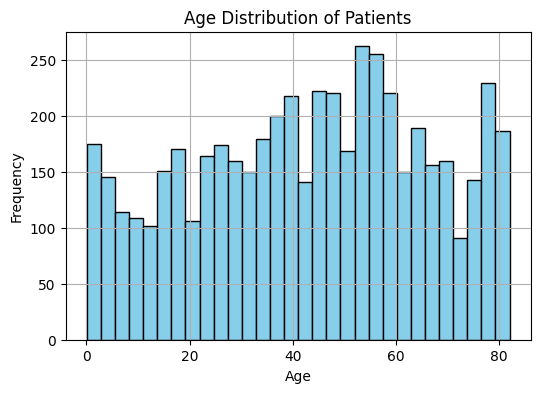

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(data['age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Between the age of 30 and 80 years strokes are most likely to occur

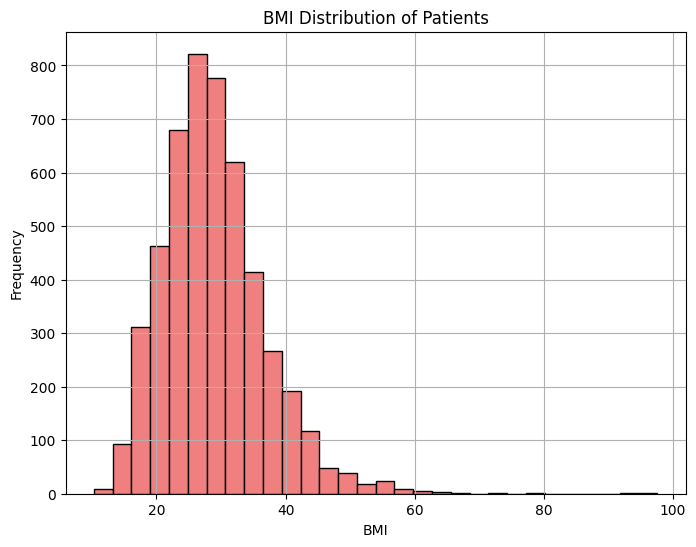

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['bmi'], bins=30, color='lightcoral', edgecolor='black')
plt.title('BMI Distribution of Patients')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


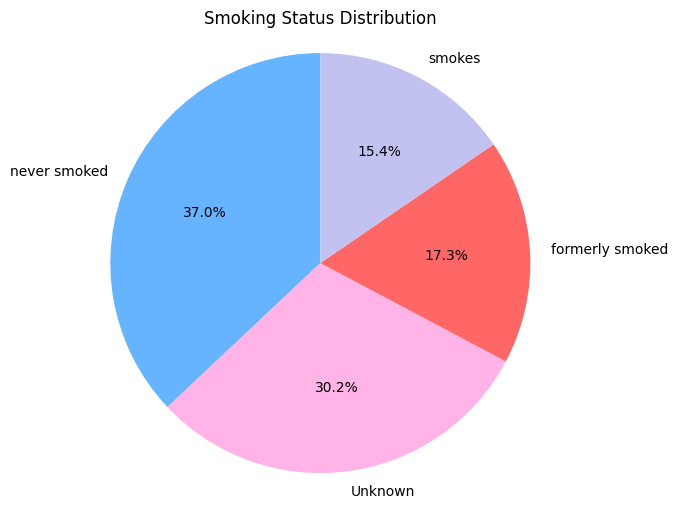

In [ ]:
# Pie chart 
plt.figure(figsize=(8, 6))
smoking_status_counts = data['smoking_status'].value_counts()
plt.pie(smoking_status_counts, labels=smoking_status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ffb3e6', '#ff6666', '#c2c2f0'])
plt.title('Smoking Status Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


This is a pie chart that depicts patients by smoking status.

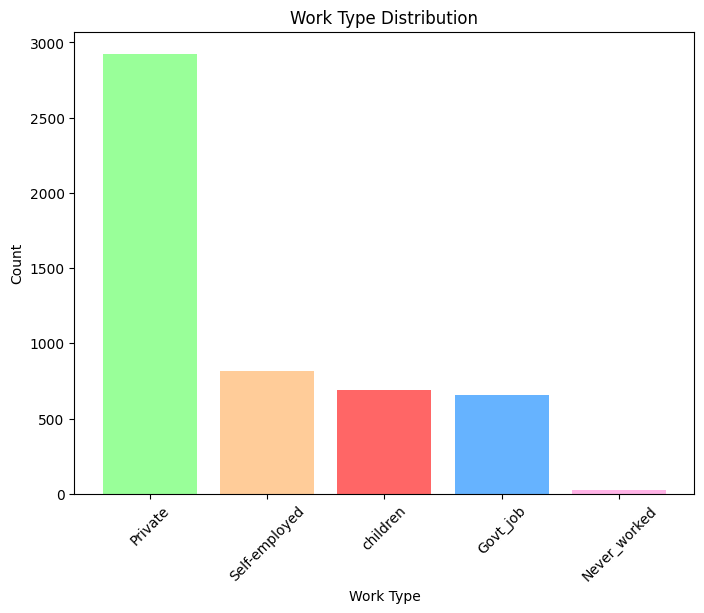

In [ ]:
# Bar plot for Work Type distribution
plt.figure(figsize=(8, 6))
work_type_counts = data['work_type'].value_counts()
plt.bar(work_type_counts.index, work_type_counts.values, color=['#99ff99', '#ffcc99', '#ff6666', '#66b3ff', '#ffb3e6'])

# Adding labels and title
plt.title('Work Type Distribution')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


Out of all the work type, Private is more common among the patients.

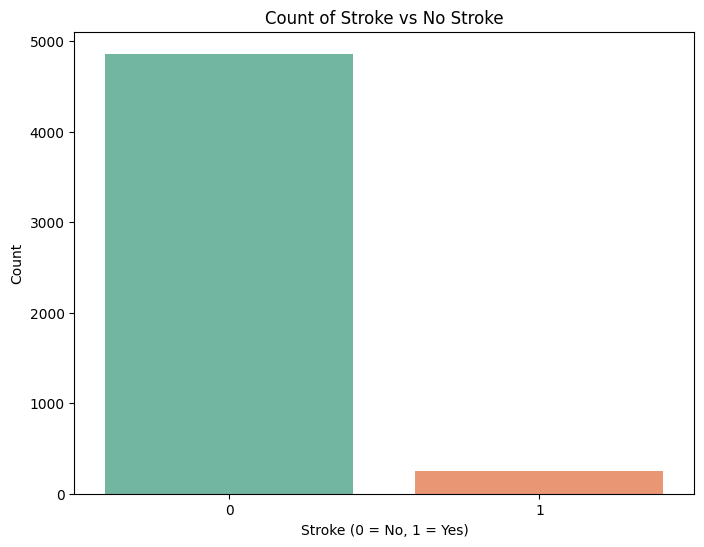

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='stroke', data=data, palette='Set2')
plt.title('Count of Stroke vs No Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


This bar chart above as we see it represents the data patients taken with code 1 as those who have had a stroke and code 0 as those who have not.

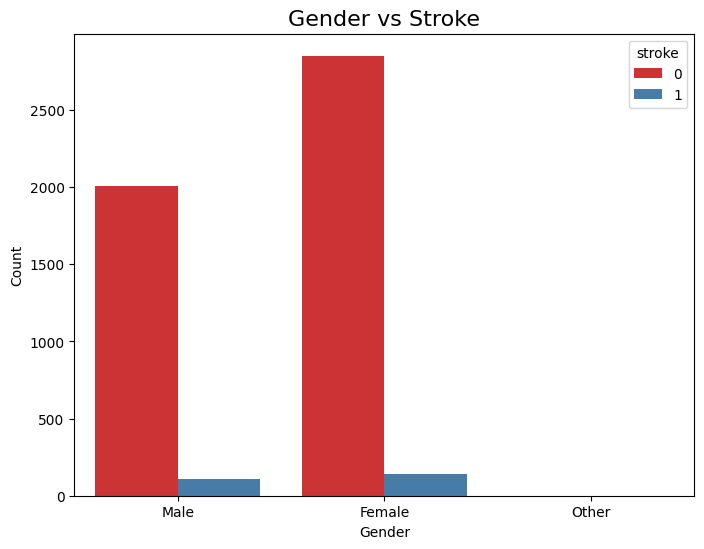

In [ ]:
# Explore categorical variable relationships with stroke
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='stroke', data=data, palette='Set1')
plt.title('Gender vs Stroke', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


This is a bar chart that demonstrates the relationship between gender and having a stroke.

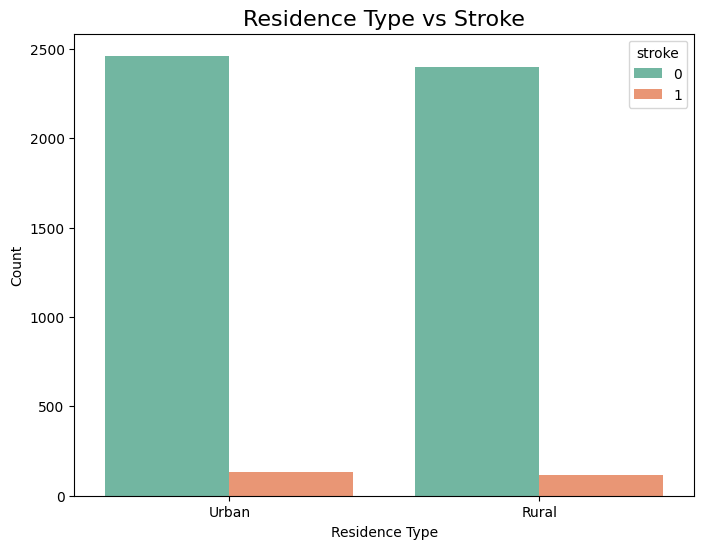

In [ ]:
# Bar plot for Stroke vs Residence Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Residence_type', hue='stroke', data=data, palette='Set2')
plt.title('Residence Type vs Stroke', fontsize=16)
plt.xlabel('Residence Type')
plt.ylabel('Count')
plt.show()


Since There are low number of stroke victims in both the rural and the urban areas, and as we observe  majority being non-stroke victims.

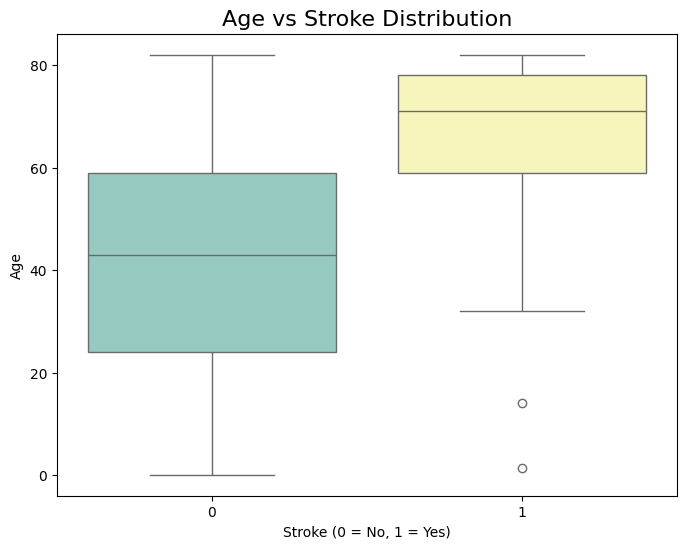

In [ ]:
# Box plot for Age vs Stroke distribution
plt.figure(figsize=(8, 6))
sns.boxplot(x='stroke', y='age', data=data, palette='Set3')
plt.title('Age vs Stroke Distribution', fontsize=16)
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()


This is an age boxplot for those who had a stroke versus those who did not. This box plot shows that those who had a stroke were older. The age value for the stroke victims not only falls mostly above the interquartile range of the non-stroke victims, but there are also some outlier points to suggest it is more likely that older people will have a stroke.

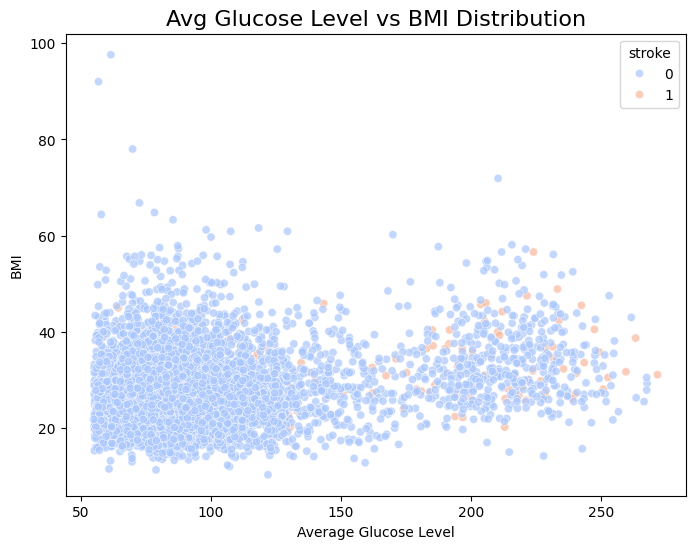

In [ ]:
# Scatter plot for Avg Glucose Level vs BMI
plt.figure(figsize=(8, 6))
sns.scatterplot(x='avg_glucose_level', y='bmi', hue='stroke', data=data, palette='coolwarm', alpha=0.7)
plt.title('Avg Glucose Level vs BMI Distribution', fontsize=16)
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.show()


The scatter plot displays the association between the average glucose level and BMI

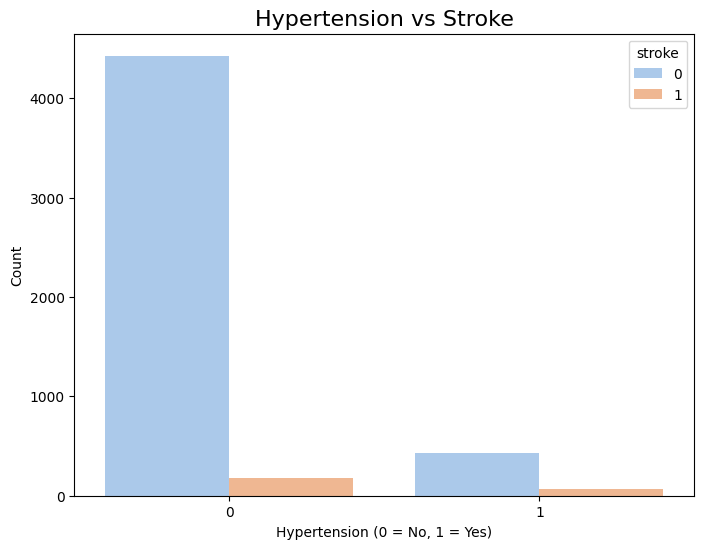

In [ ]:
# Count plot for Hypertension vs Stroke
plt.figure(figsize=(8, 6))
sns.countplot(x='hypertension', hue='stroke', data=data, palette='pastel')
plt.title('Hypertension vs Stroke', fontsize=16)
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


This bar plot displays the relationship between hypertension and stroke emergence. It shows where mostly stroke patients have the hypertension (coded as '1'). On the other hand, the non-stroke patients mostly don't have hypertension.

In [ ]:
# Display missing values
print("Missing Values:\n", missing_values)


Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64



In [ ]:
# Impute missing BMI values using the mean or median
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())  # Or use median if preferred

# Verify if missing values are handled
missing_values_after_imputation = data.isnull().sum()
print("Missing Values After Imputation:\n", missing_values_after_imputation)


Missing Values After Imputation:
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64



This indicates that this is the relative frequency of the entire dataset after the missing value was filled in the column 'bmi' with the mean. At this stage, we can fill in missing values through imputation so there are no more missing values.

# Data Preprocessing

In [ ]:
# Drop ID column
if 'id' in data.columns:
    data = data.drop(columns=['id'])

X = data.drop(columns=['heart_disease', 'stroke'])
y = data['stroke']


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Handle missing values
imputer = SimpleImputer(strategy='mean')
X_train['bmi'] = imputer.fit_transform(X_train[['bmi']])
X_test['bmi'] = imputer.transform(X_test[['bmi']])


In [ ]:
# Handle categorical encoding correctly
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [ ]:
# Using the label encoder after splitting to avoid the data leakage
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

    X_test[col] = X_test[col].cat.set_categories(X_train[col].cat.categories)

    X_train[col] = X_train[col].cat.codes
    X_test[col] = X_test[col].cat.codes

# Apply LabelEncoder to selected columns
label_encoder = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    data[col] = label_encoder.fit_transform(data[col])


# Model Devlopment

In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True),  # Set probability=True
    "XGBoost": XGBClassifier()
}


# Evaluate models

In [ ]:
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)  
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # onfusion matrix and classification report
    class_report = classification_report(y_test, y_pred)
    
    # Calculate ROC AUC 
    try:
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    except AttributeError:
        roc_auc = 'N/A' 
    
    results[model_name] = {
        'Accuracy': accuracy,
        'Classification Report': class_report,
        'ROC AUC': roc_auc
    }


In [ ]:
# Display the results
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Accuracy: {result['Accuracy']:.4f}")
    print(f"Classification Report:\n{result['Classification Report']}")
    print(f"ROC AUC: {result['ROC AUC']}")
    print("-" * 50)


Model: Logistic Regression
Accuracy: 0.9393
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

ROC AUC: 0.8474630376344086
--------------------------------------------------
Model: Decision Tree
Accuracy: 0.9110
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       960
           1       0.23      0.19      0.21        62

    accuracy                           0.91      1022
   macro avg       0.59      0.58      0.58      1022
weighted avg       0.90      0.91      0.91      1022

ROC AUC: 0.5754200268817204
--------------------------------------------------
Model: Random Forest
Accuracy: 0.9393
Classification Report:

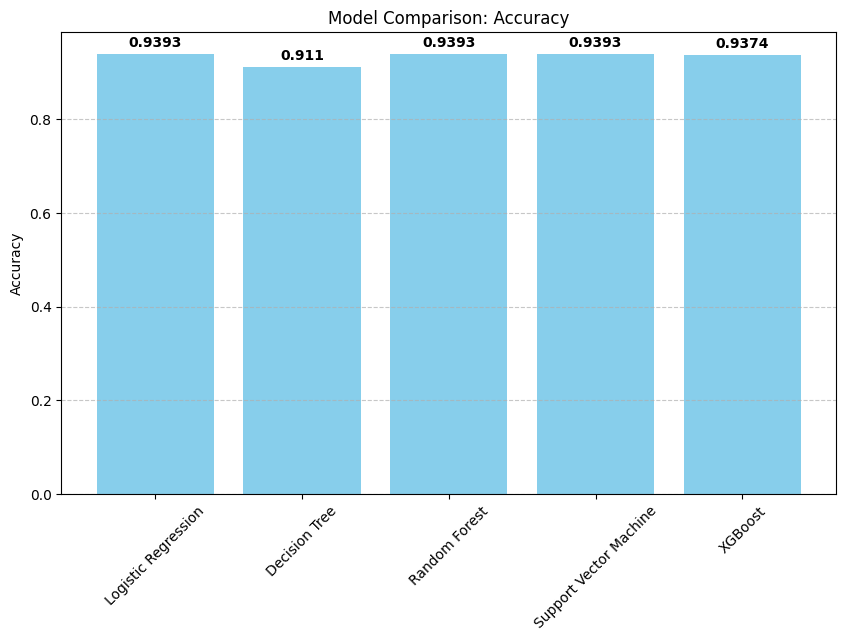

In [ ]:
# Comparison bar chart
model_names = list(results.keys())
accuracies = [result['Accuracy'] for result in results.values()]

# Plot comparison bar chart for accuracy with vertical bars
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color='skyblue')

# Add labels and title
plt.ylabel('Accuracy')
plt.title('Model Comparison: Accuracy')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid lines for better visual separation
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with its value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, round(yval, 4), ha='center', va='bottom', color='black', fontweight='bold')
plt.show()


This is a bar chart of model accuracy. In comparison with the logistic regression, the decision tree, random forest, SVM, and XGBoost data discussed in connection to the models performed in this chapter. The two most accurate models of Logistic Regression and XGBoost are almost at 94%. Hence according to my model, the decision tree and SVM got lower accuracy in comparison to other models.

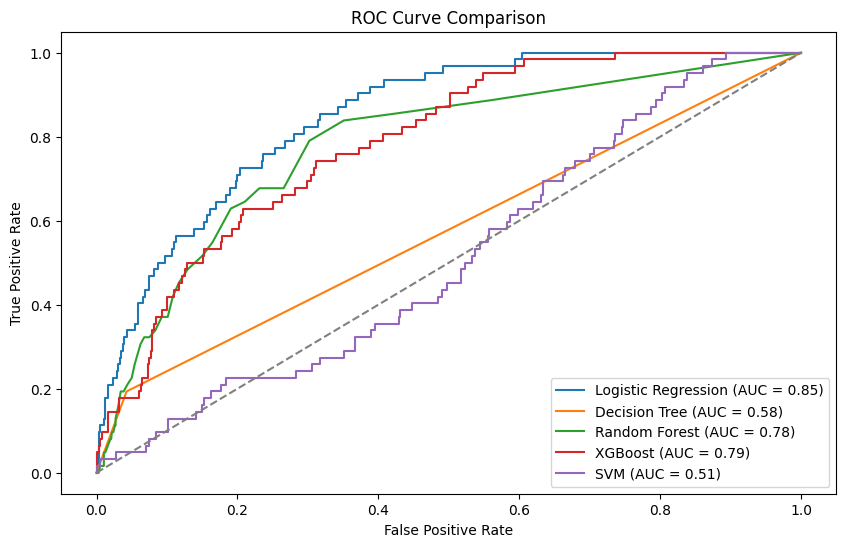

In [ ]:
# ROC curve 
plt.figure(figsize=(10, 6))

# Plot ROC curves
for model_name, model in models.items():
    if model_name != 'Support Vector Machine':  
        # ROC curve and ROC AUC score
        if hasattr(model, 'predict_proba'):
            fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
            plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f})')
        else:
            print(f"{model_name} does not support ROC curve calculation.")
            
# For the Support Vector Machine, plot its ROC curve as well
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, svm_model.predict_proba(X_test)[:, 1]):.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()


The curves represent the level of differentiation between stroke and non-stroke subjects in the models.

# Conclusion and Recommendations

To finally conclude a recap of my results from all five machine learning models reveals that for the dataset in question, stroke prediction is most successful via Logistic Regression and XGBoost. However, it was found that all models fail to appropriately assess whether a stroke occurred (class 1) because precision and recall values for this class are extremely low.